In [1]:
import pandas as pd
import numpy as np

from math import radians
from sklearn.preprocessing import LabelEncoder

In [3]:
data = pd.read_csv("merged_data.csv")

data.head()

,id,restaurant_id,rider_id,drop_lat,drop_lon,order_size,order_value,timestamp,promised_eta,actual_delivery_time_min,...,prep_capacity,manager_contact,id_rider,lat_rider,lon_rider,vehicle_type,completed_orders,shift_hours,current_load,rider_call_sign
0,1,1921,5764.0,12.967183,77.601366,7.0,843.86,2026-05-06 19:22:36,15.0,22.2,...,20.0,+91-768685777,5764.0,12.972401,77.586219,scooter,28.0,1.9,1.0,MG-390
1,2,417,3377.0,12.985586,77.615225,1.0,156.37,18/05/2026 22:56,15.0,19.2,...,8.0,+91-783763371,3377.0,12.984731,77.596576,Scooter,3768.0,9.9,1.0,EM-773
2,3,692,3424.0,12.956571,77.608251,2.0,290.15,05/06/2026 19:20,20.0,20.1,...,10.0,+91-798546660,3424.0,12.956561,77.609717,car,2643.0,1.4,2.0,NaN
3,4,140,861.0,12.950077,77.590249,2.0,164.77,2026-05-16 19:39:57,20.0,18.6,...,12.0,+91-851137177,861.0,12.984981,77.597929,4-wheeler,1673.0,10.9,0.0,KP-281
4,5,189,4881.0,12.972294,77.579577,2.0,384.46,2026-05-19 19:50:36,20.0,20.1,...,15.0,+91-789412216,4881.0,12.970247,77.581581,car,1.0,0.6,3.0,QH-561


In [4]:
drop_cols = [
    "id",
    "restaurant_id",
    "rider_id",
    "id_restaurant",
    "id_rider",
    "name"
]

for col in drop_cols:
    if col in data.columns:
        data.drop(columns=col, inplace=True)

In [5]:
num_cols = data.select_dtypes(include=np.number).columns

for col in num_cols:
    data[col].fillna(data[col].median(), inplace=True)

/tmp/ipykernel_1274/2558429060.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)


In [6]:
cat_cols = data.select_dtypes(include="object").columns

for col in cat_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

/tmp/ipykernel_1274/3513256742.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [9]:
data["timestamp"] = pd.to_datetime(data["timestamp"], format='mixed', dayfirst=True, errors='coerce')

In [10]:
data["hour"] = data["timestamp"].dt.hour

data["day"] = data["timestamp"].dt.day

data["month"] = data["timestamp"].dt.month

data["weekday"] = data["timestamp"].dt.weekday

data["is_weekend"] = data["weekday"].isin([5,6]).astype(int)

In [11]:
def peak_hour(hour):

    if 11 <= hour <= 14:
        return 1

    elif 18 <= hour <= 22:
        return 1

    else:
        return 0

data["peak_hour"] = data["hour"].apply(peak_hour)

In [12]:
def traffic(hour):

    if 7 <= hour <= 10:
        return "High"

    elif 11 <= hour <= 16:
        return "Medium"

    elif 17 <= hour <= 21:
        return "Very High"

    else:
        return "Low"

data["traffic"] = data["hour"].apply(traffic)

In [13]:
from math import sin
from math import cos
from math import sqrt
from math import atan2

R = 6371

def haversine(lat1, lon1, lat2, lon2):

    lat1 = radians(lat1)
    lon1 = radians(lon1)

    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2

    c = 2*atan2(sqrt(a), sqrt(1-a))

    return R*c

In [14]:
data["rider_restaurant_distance"] = data.apply(

    lambda x: haversine(
        x["lat_rider"],
        x["lon_rider"],
        x["lat"],
        x["lon"]
    ),

    axis=1
)

In [15]:
data["restaurant_customer_distance"] = data.apply(

    lambda x: haversine(
        x["lat"],
        x["lon"],
        x["drop_lat"],
        x["drop_lon"]
    ),

    axis=1
)

In [16]:
data["load_per_shift"] = (
    data["current_load"] /
    (data["shift_hours"] + 1)
)

In [17]:
def experience(x):

    if x < 500:
        return "Beginner"

    elif x < 2000:
        return "Intermediate"

    else:
        return "Expert"

data["rider_experience"] = data["completed_orders"].apply(experience)

In [18]:
data["restaurant_efficiency"] = (

    data["prep_capacity"] *

    data["avg_rating"]

)

In [19]:
vehicle_speed = {

    "bike":30,

    "scooter":35,

    "bicycle":15,

    "car":40

}

data["vehicle_speed"] = data["vehicle_type"].map(vehicle_speed)

In [20]:
data["estimated_travel_time"] = (

    data["restaurant_customer_distance"]

    /

    data["vehicle_speed"]

) * 60

In [21]:
def order_category(x):

    if x <= 2:
        return "Small"

    elif x <= 5:
        return "Medium"

    else:
        return "Large"

data["order_category"] = data["order_size"].apply(order_category)

In [22]:
target = "actual_delivery_time_min"

In [23]:
encoders = {}

categorical = data.select_dtypes(include="object").columns

for col in categorical:

    encoder = LabelEncoder()

    data[col] = encoder.fit_transform(data[col])

    encoders[col] = encoder

<Axes: >

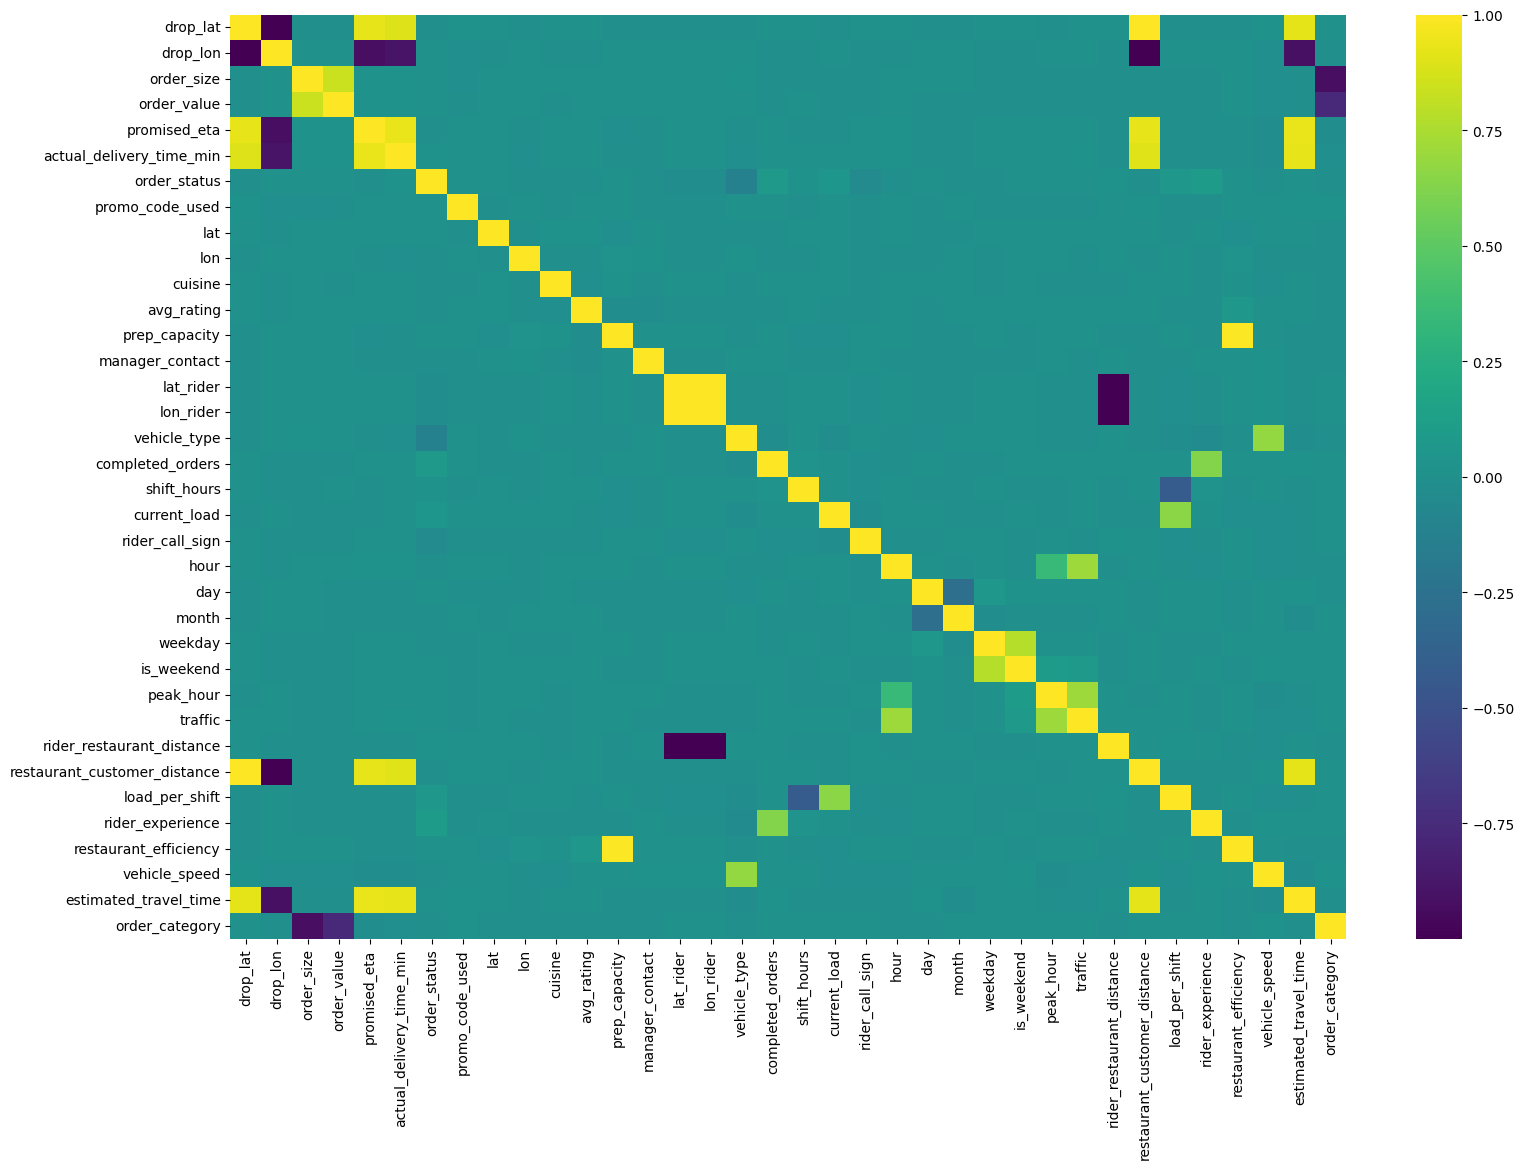

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,12))

sns.heatmap(
    data.corr(numeric_only=True),
    cmap="viridis"
)

In [25]:
data.to_csv(
    "final_dataset.csv",
    index=False
)